<a href="https://colab.research.google.com/github/Vanitha-1111-ART/AI_INTERNSHIP/blob/main/HealthCareDataset_Stroke.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


In [ ]:
d = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

In [ ]:
d.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
d['bmi'].fillna(d['bmi'].mean,inplace=True)

/tmp/ipykernel_1103/2602527439.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<bound method Series.mean of 0       36.6
1        NaN
2       32.5
3       34.4
4       24.0
        ... 
5105     NaN
5106    40.0
5107    30.6
5108    25.6
5109    26.2
Name: bmi, Length: 5110, dtype: float64>' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  d['bmi'].fillna(d['bmi'].mean,inplace=True)


In [ ]:
d.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
en = LabelEncoder()
d['gender']=en.fit_transform(d['gender'])
d['ever_married']=en.fit_transform(d['ever_married'])
d['work_type']=en.fit_transform(d['work_type'])
d['Residence_type']=en.fit_transform(d['Residence_type'])
d['smoking_status']=en.fit_transform(d['smoking_status'])

In [ ]:
x=d.drop('stroke',axis=1)
y=d[['stroke']]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [ ]:
print(x_train.head())

         id  gender   age  ...  avg_glucose_level   bmi  smoking_status
4152  12857       1  55.0  ...              73.57  28.0               3
4051  52530       1  55.0  ...             231.15  22.3               2
5076  39935       0  34.0  ...             174.37  23.0               2
874   70852       1  80.0  ...              56.99  26.7               2
3534  53897       0  61.0  ...             108.18  19.1               2

[5 rows x 11 columns]


In [ ]:
print(x_train.dtypes)

id                     int64
gender                 int64
age                  float64
hypertension           int64
heart_disease          int64
ever_married           int64
work_type              int64
Residence_type         int64
avg_glucose_level    float64
bmi                   object
smoking_status         int64
dtype: object


In [ ]:
x_train['bmi'] = pd.to_numeric(x_train['bmi'], errors='coerce')
x_test['bmi'] = pd.to_numeric(x_test['bmi'], errors='coerce')

In [ ]:
print(x_train['bmi'].head())
print(type(x_train['bmi'].iloc[0]))

4152    28.0
4051    22.3
5076    23.0
874     26.7
3534    19.1
Name: bmi, dtype: float64
<class 'numpy.float64'>


In [ ]:
s=StandardScaler()
xs=s.fit_transform(x_train)

Tensorflow Keras

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
model = keras.Sequential([keras.layers.Flatten(input_shape=(11,)),
                          keras.layers.Dense(8,activation='relu'),
                          keras.layers.Dense(2,activation='sigmoid')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
his=model.fit(xs,y_train,validation_split=0.1,epochs=20)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9339 - loss: nan - val_accuracy: 0.9560 - val_loss: nan
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9535 - loss: nan - val_accuracy: 0.9560 - val_loss: nan
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9535 - loss: nan - val_accuracy: 0.9560 - val_loss: nan
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9535 - loss: nan - val_accuracy: 0.9560 - val_loss: nan
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9535 - loss: nan - val_accuracy: 0.9560 - val_loss: nan
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9535 - loss: nan - val_accuracy: 0.9560 - val_loss: nan
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9535 - loss: nan - val_accuracy: 0.9560 - val_loss: nan
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9535 - loss: nan - val_accuracy: 0.9560 - val_loss: nan
Epoch 9/20
115/115 ━━━━━

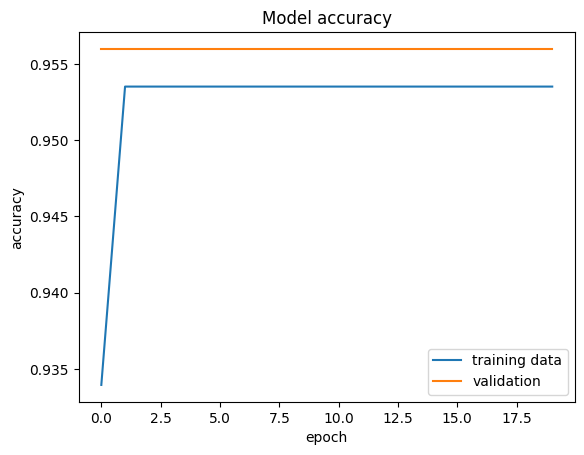

In [ ]:
plt.plot(his.history['accuracy'])
plt.plot(his.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['training data','validation'],loc='lower right')

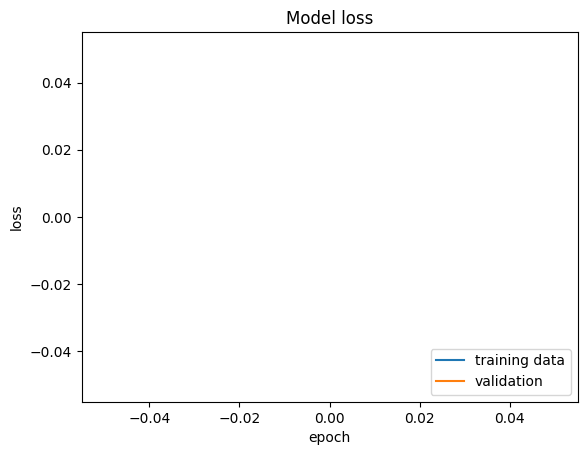

In [ ]:
plt.plot(his.history['loss'])
plt.plot(his.history['val_loss'])
plt.title('Model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['training data','validation'],loc='lower right')

In [ ]:
print(xs.shape)

(4088, 11)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344 (1.35 KB)

 Trainable params: 114 (456.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 230 (924.00 B)